# Figure 4 - Learning DendI weights for Dend Target Prop

In [49]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
figure_name = "Fig4_dendI"
model_list = ["bpLike_WT_fixedDend", "bpLike_WT_localBP", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Fixed random
Generating plots for Learned (Backprop)
Generating plots for Learned (Hebb)


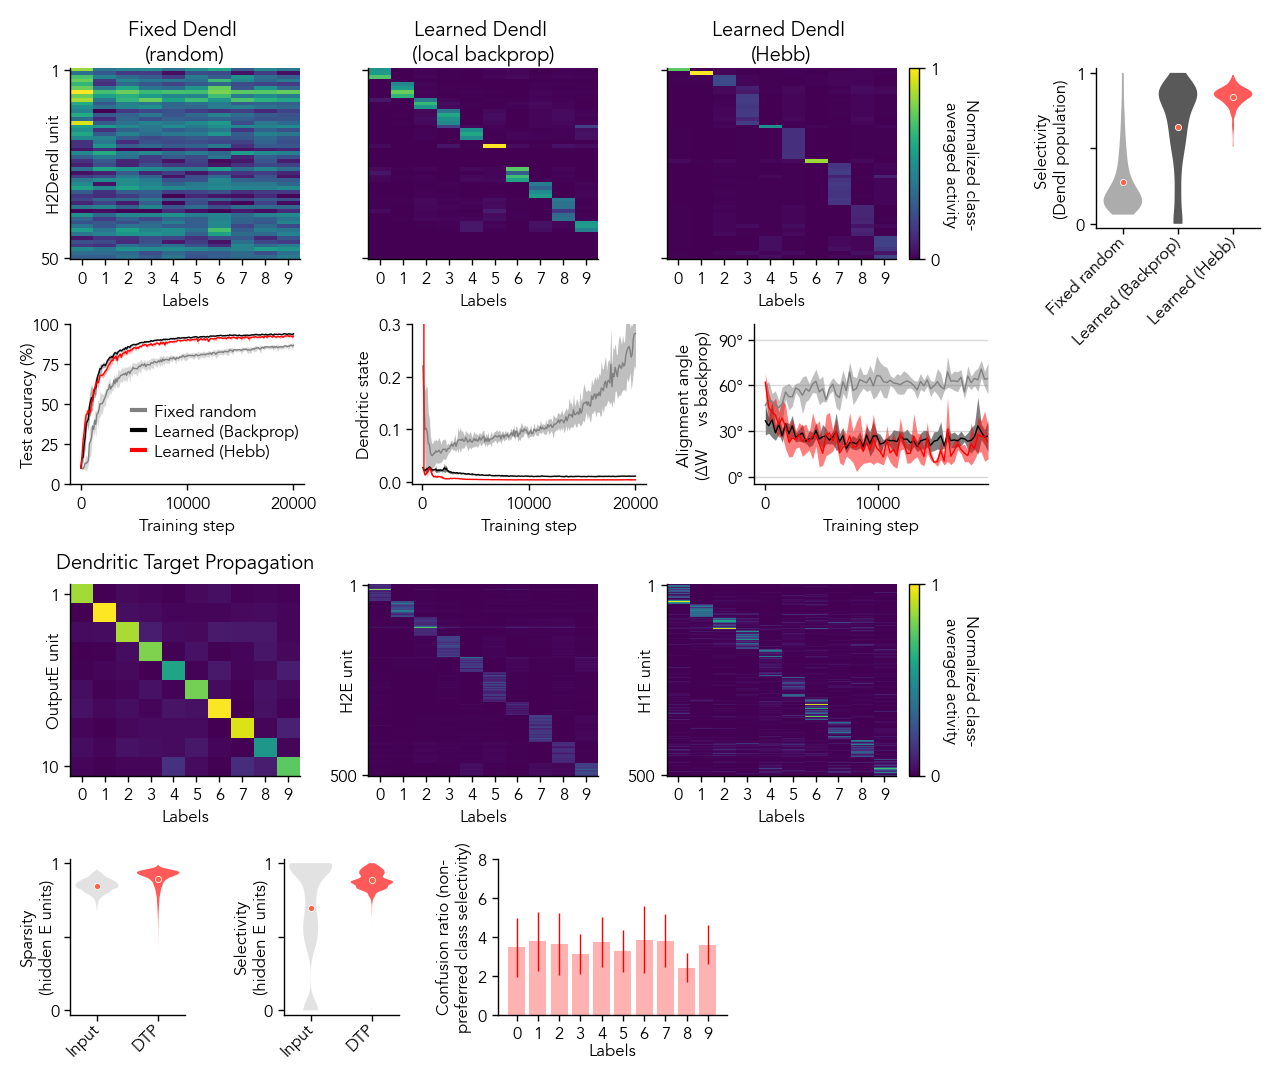

In [53]:
fig = plt.figure(figsize=(6.5, 5.2))
heatmap_axes = gs.GridSpec(nrows=3, ncols=3, figure=fig,            
                    left=0.045,right=0.68,
                    top=0.95, bottom=0.27,
                    wspace=0.3, hspace=0.35)

metrics_axes = gs.GridSpec(nrows=2, ncols=4, figure=fig,
                    left=0.045,right=0.96,
                    top=0.95, bottom=0.55,
                    wspace=0.5, hspace=0.6,
                    width_ratios=[1, 1, 1, 0.7])

bottom_axes = gs.GridSpec(nrows=1, ncols=3, figure=fig,
                    left=0.045,right=0.55,
                    top=0.19, bottom=0.04,
                    wspace=0.65, width_ratios=[1, 1, 2])

ax_dend_selectivity = fig.add_subplot(metrics_axes[0, 3])
ax_accuracy    = fig.add_subplot(metrics_axes[1, 0])
ax_dendstate   = fig.add_subplot(metrics_axes[1, 1])
ax_angle       = fig.add_subplot(metrics_axes[1, 2])
root_dir = ut.get_project_root()

if "bpLike_WT_hebbdend" in model_dict_all: # Update model label for this figure
    model_dict_all["bpLike_WT_hebbdend"]["label"] = "Learned (Hebb)"
    
for col, model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")
        population = 'H2DendI'
        example_seed = model_dict['seeds'][0] # example seed to plot

        ######################################
        # Example heatmaps for E populations
        ######################################
        ax = fig.add_subplot(heatmap_axes[0, col])
        average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
        num_units = average_pop_activity_dict[population].shape[1]
        pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=False)
        if col==len(model_list)-1:
            pos = ax.get_position()                
            cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.008, pos.height])                
            cbar = matplotlib.colorbar.ColorbarBase(cbar_ax, cmap='viridis', orientation='vertical')
            cbar.set_label('Normalized class-\naveraged activity', labelpad=14, rotation=270)
            cbar.set_ticks([0, 1])

        ax.set_yticks([0,num_units-1])
        ax.set_yticklabels([1,num_units])
        ax.set_ylabel(f'{population} unit', labelpad=-8)
        ax.set_title(model_dict["display_name"], pad=3)
        if col>0:
            ax.set_ylabel('')
            ax.set_yticklabels([])
            
        ######################################
        # Model metrics
        ######################################
        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy)
        plot_dendritic_state_all_seeds(data_dict, model_dict, ax=ax_dendstate)
        plot_angle_vs_bp_all_seeds(data_dict, model_dict, ax=ax_angle)

        populations_to_plot = [population for population in data_dict[example_seed]['average_pop_activity_dict'] if 'DendI' in population]
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_dend_selectivity, metric_name='selectivity', plot_type='violin', plot_input=False)
        ax_dend_selectivity.set_ylabel(f"Selectivity \n(DendI population)")

        legend = ax_accuracy.legend(ncol=1, bbox_to_anchor=(0.2, 0.6), loc='upper left', fontsize=6)
        for line in legend.get_lines():
            line.set_linewidth(1.5)


        ######################################
        # Dendritic target propagation
        ######################################
        if model_key == "bpLike_WT_hebbdend":
            # Activity plots: batch accuracy of each population to the test dataset
            average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
            for i, population in enumerate(["OutputE", "H2E", "H1E"]):
                ax = fig.add_subplot(heatmap_axes[2, i])
                pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=False)
                num_units = average_pop_activity_dict[population].shape[1]
                ax.set_yticks([0,num_units-1])
                ax.set_yticklabels([1,num_units])
                ax.set_ylabel(f'{population} unit', labelpad=-8 if i==0 else -10)
                if i==0:
                    ax.set_title("Dendritic Target Propagation")
            pos = ax.get_position()                
            cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.008, pos.height])                
            cbar = matplotlib.colorbar.ColorbarBase(cbar_ax, cmap='viridis', orientation='vertical')
            cbar.set_label('Normalized class-\naveraged activity', labelpad=14, rotation=270)
            cbar.set_ticks([0, 1])

            # Plot sparsity and selectivity of hidden layers
            ax_sparsity = fig.add_subplot(bottom_axes[0])
            ax_selectivity = fig.add_subplot(bottom_axes[1])
            model_dict["label"] = "DTP"
            populations_to_plot = ['H1E', 'H2E']
            plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_sparsity, metric_name='sparsity', plot_type='violin', side='both')
            plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_selectivity, metric_name='selectivity', plot_type='violin', side='both')
            ax_sparsity.set_ylabel(f"Sparsity\n(hidden E units)", labelpad=-2)
            ax_selectivity.set_ylabel(f"Selectivity\n(hidden E units)", labelpad=-2)

        # Confusion plots for Dend Target Prop
        if model_key == "bpLike_WT_hebbdend":
            ax = fig.add_subplot(bottom_axes[2])
            plot_confusion_all_seeds(data_dict, model_dict, ax=ax)


fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)